In [10]:
!pip install darts --quiet
!pip install pytorch-lightning --quiet

In [11]:
pip show darts


Name: darts
Version: 0.38.0
Summary: A python library for easy manipulation and forecasting of time series.
Home-page: https://unit8co.github.io/darts/
Author: 
Author-email: 
License: Apache License 2.0
Location: /Users/jeanvanbeneden/miniforge3/envs/elec-forecast/lib/python3.11/site-packages
Requires: holidays, joblib, matplotlib, narwhals, nfoursid, numpy, pandas, pyod, pytorch-lightning, requests, scikit-learn, scipy, shap, statsmodels, tensorboardX, torch, tqdm, typing-extensions, xarray
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip show pytorch-lightning

Name: pytorch-lightning
Version: 2.5.2
Summary: PyTorch Lightning is the lightweight PyTorch wrapper for ML researchers. Scale your models. Write less boilerplate.
Home-page: https://github.com/Lightning-AI/lightning
Author: Lightning AI et al.
Author-email: pytorch@lightning.ai
License: Apache-2.0
Location: /Users/jeanvanbeneden/miniforge3/envs/elec-forecast/lib/python3.11/site-packages
Requires: fsspec, lightning-utilities, packaging, PyYAML, torch, torchmetrics, tqdm, typing-extensions
Required-by: darts
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse


print("finish")

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


finish


In [15]:
df = pd.read_csv('../data/processed/prices_belgium_clean.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f"{len(df)} hrs")
print(f"{df['datetime'].min()} to {df['datetime'].max()}")
print(f"\n{df.head()}")

7560 hrs
2024-12-31 23:00:00 to 2025-11-11 22:00:00

             datetime  price
0 2024-12-31 23:00:00  10.62
1 2025-01-01 00:00:00  10.27
2 2025-01-01 01:00:00   8.38
3 2025-01-01 02:00:00   6.61
4 2025-01-01 03:00:00   2.29


In [19]:
#temporal features

df['hour']=df['datetime'].dt.hour
df['day_of_week']=df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend']= df['day_of_week'].isin([5, 6]).astype(int)

print(df[['datetime', 'price', 'hour', 'day_of_week', 'is_weekend']].head())

             datetime  price  hour  day_of_week  is_weekend
0 2024-12-31 23:00:00  10.62    23            1           0
1 2025-01-01 00:00:00  10.27     0            2           0
2 2025-01-01 01:00:00   8.38     1            2           0
3 2025-01-01 02:00:00   6.61     2            2           0
4 2025-01-01 03:00:00   2.29     3            2           0


In [20]:
train_end= pd.Timestamp('2025-06-30 23:00:00')
val_end=pd.Timestamp('2025-08-31 23:00:00')

train =df[df['datetime'] <= train_end].copy()
val=df[(df['datetime'] > train_end) & (df['datetime'] <= val_end)].copy()
test=df[df['datetime'] > val_end].copy()

In [25]:

#Timeseries object from darts

train_target = TimeSeries.from_dataframe(
    train, 
    time_col='datetime', 
    value_cols='price',
    freq='H'  #hrly
)

val_target = TimeSeries.from_dataframe(
    val, 
    time_col='datetime', 
    value_cols='price',
    freq='H'
)

test_target = TimeSeries.from_dataframe(
    test, 
    time_col='datetime', 
    value_cols='price',
    freq='H'
)


print(f"Train target : {len(train_target)} timesteps")
print(f"Val target   : {len(val_target)} timesteps")
print(f"Test target  : {len(test_target)} timesteps")


train_covariates = TimeSeries.from_dataframe(
    train,
    time_col='datetime',
    value_cols=['hour', 'day_of_week', 'month', 'is_weekend'],
    freq='H'
)

val_covariates =TimeSeries.from_dataframe(
    val,
    time_col='datetime',
    value_cols=['hour', 'day_of_week', 'month', 'is_weekend'],
    freq='H'
)

test_covariates=TimeSeries.from_dataframe(
    test,
    time_col='datetime',
    value_cols=['hour', 'day_of_week', 'month', 'is_weekend'],
    freq='H'
)

Train target : 4345 timesteps
Val target   : 1488 timesteps
Test target  : 1727 timesteps


In [26]:
#TFT works better with normalized data

scaler_target = Scaler()
train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)
test_target_scaled = scaler_target.transform(test_target)

scaler_covariates = Scaler()
train_covariates_scaled = scaler_covariates.fit_transform(train_covariates)
val_covariates_scaled = scaler_covariates.transform(val_covariates)
test_covariates_scaled = scaler_covariates.transform(test_covariates)
print(f"min {train['price'].min():.2f} to {train_target_scaled.values().min():.3f}")
print(f"max {train['price'].max():.2f} to {train_target_scaled.values().max():.3f}")

min -462.33 to 0.000
max 473.28 to 1.000


In [28]:
model = TFTModel(
    input_chunk_length=168,        # Lookback : 7 days
    output_chunk_length=24,        # Forecast : J+1
    hidden_size=32,                # LSTM Size
    lstm_layers=1,                 
    num_attention_heads=4,        
    dropout=0.1,               
    batch_size=16,                
    n_epochs=20,                  
    add_relative_index=True,       
    optimizer_kwargs={"lr": 1e-3}, # Learning rate
    random_state=42,
    force_reset=True,
    save_checkpoints=False        
)


In [ ]:
model.fit(
    series=train_target_scaled,
    future_covariates=train_covariates_scaled,
    val_series=val_target_scaled,
    val_future_covariates=val_covariates_scaled,
    verbose=True
)

print("\ntrained")

In [30]:
import torch
torch.set_default_device('cpu')

model = TFTModel(
    input_chunk_length=168,
    output_chunk_length=24,
    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=16,
    n_epochs=20,
    add_relative_index=True,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    save_checkpoints=False,
    pl_trainer_kwargs={
        "accelerator": "cpu",  
        "enable_progress_bar": True
    }
)


print("model ok")

model.fit(
    series=train_target_scaled,
    future_covariates=train_covariates_scaled,
    val_series=val_target_scaled,
    val_future_covariates=val_covariates_scaled,
    verbose=True
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 6.0 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 5.0 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 4.3 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNet

model ok


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

Training: |                                                                      | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=168, output_chunk_length=24, batch_size=16, n_epochs=20, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True, save_checkpoints=False, pl_trainer_kwargs={'accelerator': 'cpu', 'enable_progress_bar': True})

In [33]:
full_covariates_scaled = train_covariates_scaled.concatenate(
    val_covariates_scaled, 
    ignore_time_axis=False
).concatenate(
    test_covariates_scaled,
    ignore_time_axis=False
)


full_target_scaled = train_target_scaled.concatenate(
    val_target_scaled,
    ignore_time_axis=False
).concatenate(
    test_target_scaled,
    ignore_time_axis=False
)


print(f"Full target: {len(full_target_scaled)} hrs")
print(f"Full covariates : {len(full_covariates_scaled)} hrs")


#Now test pred
predictions_scaled = model.predict(
    n=len(test_target),
    series=full_target_scaled[:len(train_target) + len(val_target)],  # Jusqu'à la fin du val
    future_covariates=full_covariates_scaled,  # Toutes les covariates
    verbose=True
)

print(f"\n Pred generated : {len(predictions_scaled)} hrs")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Full target: 7560 hrs
Full covariates : 7560 hrs


Predicting: |                                                                    | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/1 [00:00<?, ?it/s]


 Pred generated : 1727 hrs


In [36]:
predictions = scaler_target.inverse_transform(predictions_scaled)

# numpy conv
y_true_tft = test_target.values().flatten()
y_pred_tft = predictions.values().flatten()


print(f"true : {len(y_true_tft)} hrs")
print(f"tft pred: {len(y_pred_tft)} hrs")

print(f"\n5 first hrs :")
for i in range(5):
    print(f"   hour {i+1}: true={y_true_tft[i]:.2f} € | predict={y_pred_tft[i]:.2f} € | error={abs(y_true_tft[i]-y_pred_tft[i]):.2f} €")

true : 1727 hrs
tft pred: 1727 hrs

5 first hrs :
   hour 1: true=66.14 € | predict=53.42 € | error=12.72 €
   hour 2: true=61.70 € | predict=68.28 € | error=6.58 €
   hour 3: true=61.85 € | predict=64.59 € | error=2.74 €
   hour 4: true=71.14 € | predict=76.28 € | error=5.14 €
   hour 5: true=67.63 € | predict=89.23 € | error=21.60 €


In [39]:


def forecast_eval(y_true, y_pred, model_name="Model"):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    
    y_true_clean= y_true[mask]
    y_pred_clean=y_pred[mask]
    mae = np.mean(np.abs(y_true_clean - y_pred_clean))
    rmse = np.sqrt(np.mean((y_true_clean - y_pred_clean)**2))
    mask_positive = y_true_clean > 1.0
    if mask_positive.sum() > 0:
        mape = np.mean(np.abs((y_true_clean[mask_positive] -y_pred_clean[mask_positive])/y_true_clean[mask_positive]))* 100
    else:
        mape = np.nan
    
    return {
        'model': model_name,
        'mae': mae,
        'rmse': rmse,
        'mape': mape
    }
    
results_tft = forecast_eval(y_true_tft, y_pred_tft, "TFT (J+1)")


comparison = pd.DataFrame([
    {'model': 'Naive Persistence', 'mae': 25.02, 'rmse': 35.30, 'mape': 85.31},
    {'model': 'ARIMA(1,1,1)', 'mae': 27.19, 'rmse': 40.06, 'mape': 70.84},
    {'model': 'Seasonal Naive', 'mae': 37.15, 'rmse': 48.23, 'mape': 141.39},
    results_tft
])

print(comparison.to_string(index=False))

best_mae_idx = comparison['mae'].idxmin()
best_model = comparison.loc[best_mae_idx, 'model']
best_mae = comparison.loc[best_mae_idx, 'mae']

print("\n" + "="*70)
print(f"🎯 MEILLEUR MODÈLE : {best_model}")
print(f"   MAE = {best_mae:.2f} €/MWh")
print("="*70)

# Analyser TFT vs Naive
tft_mae = results_tft['mae']
naive_mae = 25.02
improvement = ((naive_mae - tft_mae) / naive_mae) * 100

print(f"\n📊 ANALYSE TFT vs NAIVE :")
if tft_mae < naive_mae:
    print(f"   ✅ TFT GAGNE !")
    print(f"   Amélioration : {improvement:.2f}%")
    print(f"   TFT est {improvement:.2f}% meilleur que Naive")
    print(f"\n   🎉 Le deep learning bat les baselines !")
elif tft_mae < naive_mae * 1.05:  # Moins de 5% de différence
    print(f"   ⚖️  TFT et Naive sont similaires")
    print(f"   Différence : {abs(improvement):.2f}%")
    print(f"\n   💡 TFT n'apporte pas d'amélioration significative")
    print(f"      → Le marché est fondamentalement imprévisible au-delà de l'inertie")
else:
    print(f"   ⚠️  TFT est moins bon que Naive")
    print(f"   Dégradation : {-improvement:.2f}%")
    print(f"\n   💡 Observation importante :")
    print(f"      → Même le deep learning ne capture pas les patterns")
    print(f"      → Confirme l'hypothèse de non-stationnarité stratégique")
    print(f"      → Justifie le besoin d'approches game-theoretic (SYCAMORE)")


            model       mae      rmse       mape
Naive Persistence 25.020000 35.300000  85.310000
     ARIMA(1,1,1) 27.190000 40.060000  70.840000
   Seasonal Naive 37.150000 48.230000 141.390000
        TFT (J+1) 44.383534 56.474275 165.284977

🎯 MEILLEUR MODÈLE : Naive Persistence
   MAE = 25.02 €/MWh

📊 ANALYSE TFT vs NAIVE :
   ⚠️  TFT est moins bon que Naive
   Dégradation : 77.39%

   💡 Observation importante :
      → Même le deep learning ne capture pas les patterns
      → Confirme l'hypothèse de non-stationnarité stratégique
      → Justifie le besoin d'approches game-theoretic (SYCAMORE)


In [41]:
print("🔍 DIAGNOSTIC TFT")
print("="*70)

# 1. Vérifier les premières prédictions
print("\n📊 Comparaison des 10 premières heures :")
for i in range(10):
    print(f"Heure {i+1}: Réel={y_true_tft[i]:7.2f} € | TFT={y_pred_tft[i]:7.2f} € | Erreur={abs(y_true_tft[i]-y_pred_tft[i]):6.2f} €")

# 2. Statistiques des prédictions
print(f"\n📈 Statistiques :")
print(f"Réel  : min={y_true_tft.min():.2f} | max={y_true_tft.max():.2f} | mean={y_true_tft.mean():.2f}")
print(f"TFT   : min={y_pred_tft.min():.2f} | max={y_pred_tft.max():.2f} | mean={y_pred_tft.mean():.2f}")

# 3. Vérifier si TFT prédit des valeurs cohérentes
if y_pred_tft.mean() < 0 or y_pred_tft.mean() > 200:
    print("\n⚠️  PROBLÈME DÉTECTÉ : Les prédictions sont dans une plage anormale !")
    print("   Possible problème de scaling/dé-normalisation")



🔍 DIAGNOSTIC TFT

📊 Comparaison des 10 premières heures :
Heure 1: Réel=  66.14 € | TFT=  53.42 € | Erreur= 12.72 €
Heure 2: Réel=  61.70 € | TFT=  68.28 € | Erreur=  6.58 €
Heure 3: Réel=  61.85 € | TFT=  64.59 € | Erreur=  2.74 €
Heure 4: Réel=  71.14 € | TFT=  76.28 € | Erreur=  5.14 €
Heure 5: Réel=  67.63 € | TFT=  89.23 € | Erreur= 21.60 €
Heure 6: Réel=  96.06 € | TFT= 120.85 € | Erreur= 24.79 €
Heure 7: Réel=  97.33 € | TFT=  89.90 € | Erreur=  7.43 €
Heure 8: Réel=  78.97 € | TFT=  99.28 € | Erreur= 20.31 €
Heure 9: Réel=  48.79 € | TFT=  24.73 € | Erreur= 24.06 €
Heure 10: Réel=  35.50 € | TFT=  14.34 € | Erreur= 21.16 €

📈 Statistiques :
Réel  : min=-53.40 | max=340.79 | mean=70.99
TFT   : min=-156.74 | max=213.16 | mean=70.28


In [42]:

# Configuration AMÉLIORÉE
model_v2 = TFTModel(
    input_chunk_length=168,        # 7 jours (OK)
    output_chunk_length=24,        # 24h (OK)
    hidden_size=128,               # 32 → 128 (4× plus de capacité)
    lstm_layers=2,                 # 1 → 2 (plus de profondeur)
    num_attention_heads=4,         # OK
    dropout=0.2,                   # 0.1 → 0.2 (plus de régularisation)
    batch_size=32,                 # 16 → 32 (apprentissage plus stable)
    n_epochs=50,                   # 20 → 50 (plus de temps pour apprendre)
    add_relative_index=True,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    save_checkpoints=False,
    pl_trainer_kwargs={
        "accelerator": "cpu",
        "enable_progress_bar": True
    }
)


print("\nv2 train")

model_v2.fit(
    series=train_target_scaled,
    future_covariates=train_covariates_scaled,
    val_series=val_target_scaled,
    val_future_covariates=val_covariates_scaled,
    verbose=True
)

print("\nv2 finished")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 19.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 16.5 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 66.3 K | train
7  | static_context_hidden_encoder_grn | _GatedResidualNet

✅ Configuration améliorée :
   Hidden size : 32 → 128 (4× plus puissant)
   LSTM layers : 1 → 2 (plus profond)
   Epochs      : 20 → 50 (plus d'apprentissage)
   Batch size  : 16 → 32 (plus stable)

🔥 Entraînement V2 en cours...
   (Prends un café, ça va prendre ~15 minutes)


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

Training: |                                                                      | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



✅ ENTRAÎNEMENT V2 TERMINÉ !


In [48]:
full_covariates_scaled = train_covariates_scaled.concatenate(
    val_covariates_scaled, 
    ignore_time_axis=False
).concatenate(
    test_covariates_scaled,
    ignore_time_axis=False
)


full_target_scaled = train_target_scaled.concatenate(
    val_target_scaled,
    ignore_time_axis=False
).concatenate(
    test_target_scaled,
    ignore_time_axis=False
)


print(f"Full target: {len(full_target_scaled)} hrs")
print(f"Full covariates : {len(full_covariates_scaled)} hrs")


#Now test pred
predictions_scaled = model.predict(
    n=len(test_target),
    series=full_target_scaled[:len(train_target) + len(val_target)],  # Jusqu'à la fin du val
    future_covariates=full_covariates_scaled,  # Toutes les covariates
    verbose=True
)

print(f"\n Pred generated : {len(predictions_scaled)} hrs")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Full target: 7560 hrs
Full covariates : 7560 hrs


Predicting: |                                                                    | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/1 [00:00<?, ?it/s]


 Pred generated : 1727 hrs


In [49]:
predictions = scaler_target.inverse_transform(predictions_scaled)

# numpy conv
y_true_tft_v2 = test_target.values().flatten()
y_pred_tft_v2 = predictions.values().flatten()


print(f"true : {len(y_true_tft_v2)} hrs")
print(f"tft pred: {len(y_pred_tft_v2)} hrs")

print(f"\n5 first hrs :")
for i in range(5):
    print(f"   hour {i+1}: true={y_true_tft_v2[i]:.2f} € | predict={y_pred_tft_v2[i]:.2f} € | error={abs(y_true_tft_v2[i]-y_pred_tft_v2[i]):.2f} €")

true : 1727 hrs
tft pred: 1727 hrs

5 first hrs :
   hour 1: true=66.14 € | predict=82.69 € | error=16.55 €
   hour 2: true=61.70 € | predict=44.58 € | error=17.12 €
   hour 3: true=61.85 € | predict=51.58 € | error=10.27 €
   hour 4: true=71.14 € | predict=44.17 € | error=26.97 €
   hour 5: true=67.63 € | predict=84.28 € | error=16.65 €


In [51]:
results_tft_v2 = forecast_eval(y_true_tft_v2, y_pred_tft_v2, "TFT (J+1)")


comparison = pd.DataFrame([
    {'model': 'Naive Persistence', 'mae': 25.02, 'rmse': 35.30, 'mape': 85.31},
    {'model': 'ARIMA(1,1,1)', 'mae': 27.19, 'rmse': 40.06, 'mape': 70.84},
    {'model': 'Seasonal Naive', 'mae': 37.15, 'rmse': 48.23, 'mape': 141.39},
    results_tft,
    results_tft_v2
])

print(comparison.to_string(index=False))

best_mae_idx = comparison['mae'].idxmin()
best_model = comparison.loc[best_mae_idx, 'model']
best_mae = comparison.loc[best_mae_idx, 'mae']


print(f"\nbest model : {best_model}")
print(f"\nmae= {best_mae:.2f} €/MWh")



tft_mae = results_tft['mae']
naive_mae = 25.02
improvement = ((naive_mae - tft_mae) / naive_mae) * 100

print(f"\ntft vs naive:")
if tft_mae < naive_mae:
    print(f"tft win!")
    print(f"improvement : {improvement:.2f}%")

elif tft_mae < naive_mae * 1.05:  
    print(f"tft & naive similar")
    print(f"diff : {abs(improvement):.2f}%")

else:
    print(f"tft less good than naive")
    print(f"diff : {-improvement:.2f}%")


            model       mae      rmse       mape
Naive Persistence 25.020000 35.300000  85.310000
     ARIMA(1,1,1) 27.190000 40.060000  70.840000
   Seasonal Naive 37.150000 48.230000 141.390000
        TFT (J+1) 44.383534 56.474275 165.284977
        TFT (J+1) 45.469758 57.193585 170.439207

best model : Naive Persistence

mae= 25.02 €/MWh

tft vs naive:
tft less good than naive
diff : 77.39%


4345
1727
1727
[ 10.62  10.27   8.38 ... 122.65 111.28  95.37]


Text(0.5, 1.0, 'comp between TFT pred (v1-purple, v2-blue) vs true val on 250 pts of the set')

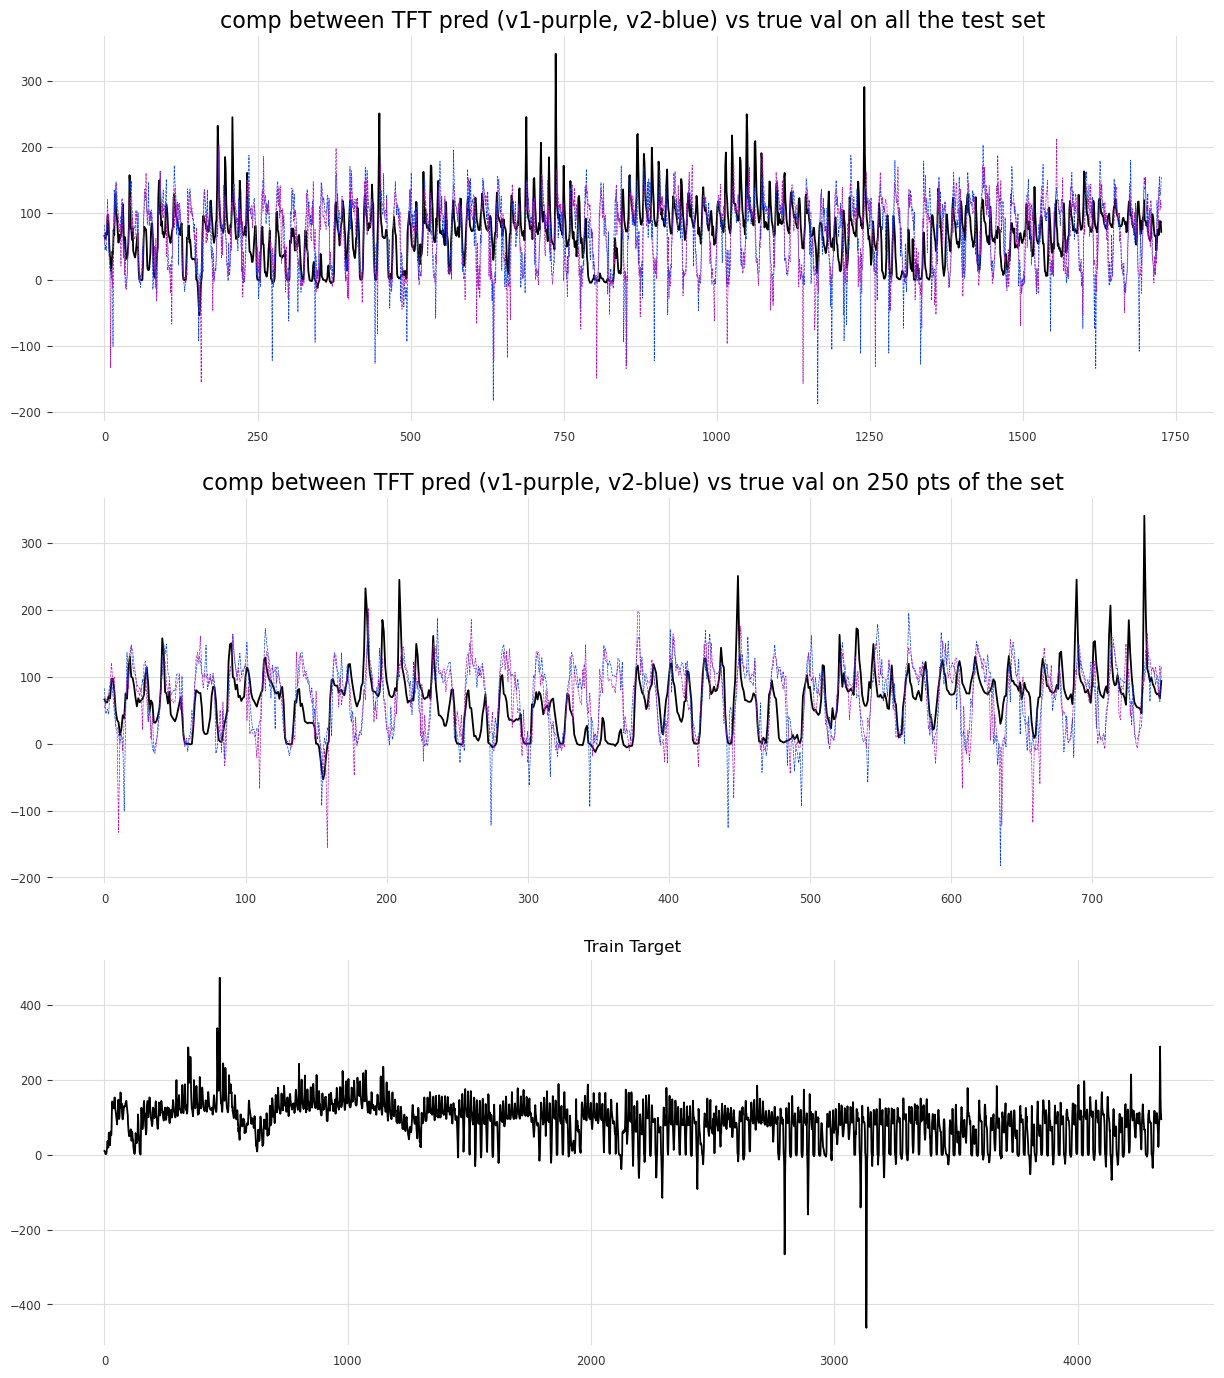

In [112]:
import matplotlib.pyplot as plt
print(len(train_target))

xaxis=np.arange(0,len(y_true_tft_v2), 1)
xaxis2=np.arange(0, len(train_target),1)
train_target_arr = train_target.values().reshape(-1)

print(len(y_true_tft_v2))
print(len(xaxis))
print(train_target_arr)
fig, ax=plt.subplots(3,1,figsize=(15, 17))

ax[0].plot(xaxis, y_true_tft_v2)
ax[0].plot(
    xaxis,
    y_pred_tft_v2,
    linestyle='--',  
    linewidth=0.5      
)
ax[0].plot(
    xaxis,
    y_pred_tft,
    linestyle='--',  
    linewidth=0.5      
)

ax[1].plot(xaxis[0:750], y_true_tft_v2[0:750])
ax[1].plot(
    xaxis[0:750],
    y_pred_tft_v2[0:750],
    linestyle='--',  
    linewidth=0.5      
)

ax[1].plot(
    xaxis[0:750],
    y_pred_tft[0:750],
    linestyle='--',  
    linewidth=0.5      
)

ax[2].plot(xaxis2, train_target_arr)
ax[2].set_title("Train Target")


ax[0].set_title("comp between TFT pred (v1-purple, v2-blue) vs true val on all the test set", fontsize=16)
ax[1].set_title("comp between TFT pred (v1-purple, v2-blue) vs true val on 250 pts of the set", fontsize=16)

In [124]:
min0=0
summ=0
for i in range(len(train_target_arr)):
    if train_target_arr[i]<0:
        summ+=1
        if train_target_arr[i]<min0:
            
            min0=train_target_arr[i]
            

print("percentage of neg spikes on the training ",summ/len(train_target_arr)*100)
print("min : " ,min0)
summ1=0
min1=0
for i in range(len(y_pred_tft_v2)):
    if y_pred_tft_v2[i]<0 :
        summ1+=1
        if y_pred_tft_v2[i]<min1 :
            
            min1=y_pred_tft_v2[i]

print("percentage of neg spikes on the pred ",summ1/len(y_pred_tft_v2)*100)
print("min : ", min1)

summ2=0
min2=0
for i in range(len(y_true_tft_v2)):
    if y_true_tft_v2[i]<0 :
        summ2+=1
        if y_true_tft_v2[i]<min2 :
            
            min2=y_true_tft_v2[i]

print("percentage of neg spikes on the targets ",summ2/len(y_true_tft_v2)*100)
print("min : ", min2)

percentage of neg spikes on the training  8.308400460299195
min :  -462.33
percentage of neg spikes on the pred  8.280254777070063
min :  -187.2371787495709
percentage of neg spikes on the targets  5.037637521713955
min :  -53.4
